In [2]:
#Muhammad Hashmi 24i-2037 Ds-5a

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("Sample - Superstore.csv",encoding="cp1252")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Mean of Sales: 229.85800083049833
Median of Sales: 54.489999999999995
Skewness of Sales: 12.97275234181623


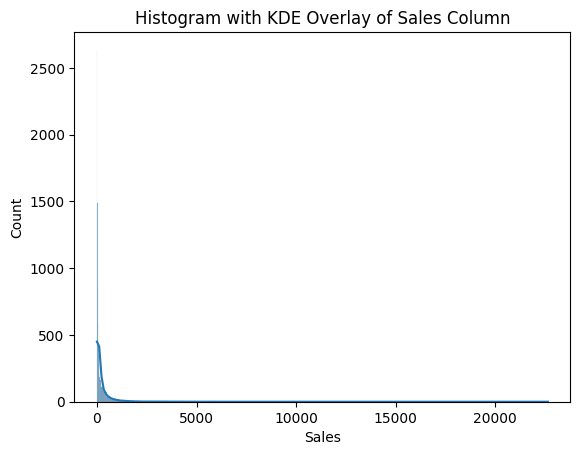

In [ ]:

# task 1
hist = sns.histplot(df['Sales'], kde=True)
plt.title('Histogram with KDE Overlay of Sales Column')
mean_sales = df['Sales'].mean()
median_sales = df['Sales'].median()
print(f"Mean of Sales: {mean_sales}")
print(f"Median of Sales: {median_sales}")
skewness = df['Sales'].skew()
print(f"Skewness of Sales: {skewness}")
# it is right skewed, mean is greater than median, so the mean is not a good measure of central tendency for this distribution.
# to summarize we will use mean as it is using complete dataset.

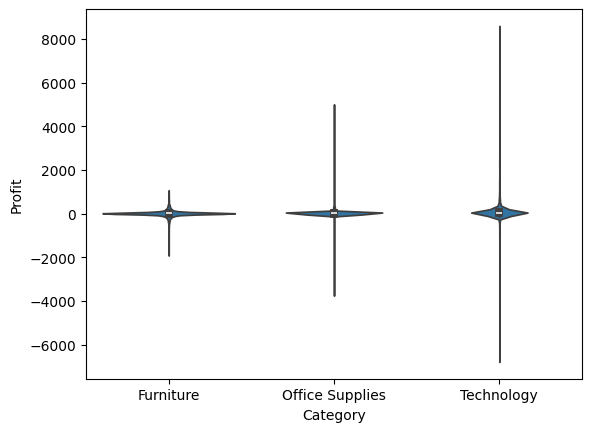

In [11]:
# task 2

violins = sns.violinplot(x='Category', y='Profit', data=df)


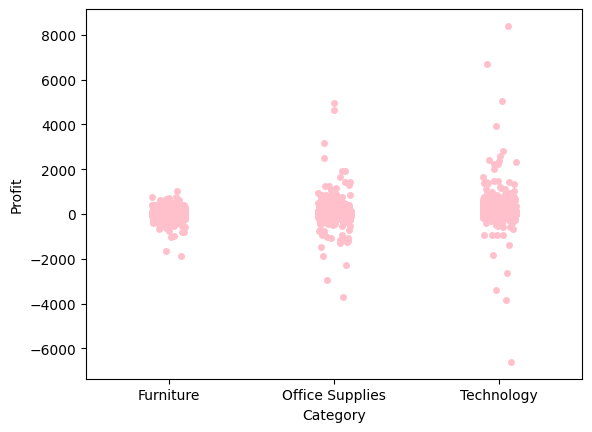

In [ ]:
strip_plot = sns.stripplot(x='Category', y='Profit', data=df, jitter=True, color='pink')
# strip plot is better imo because it is showing every single point with the help of jittering. violin only shows distribution as whole

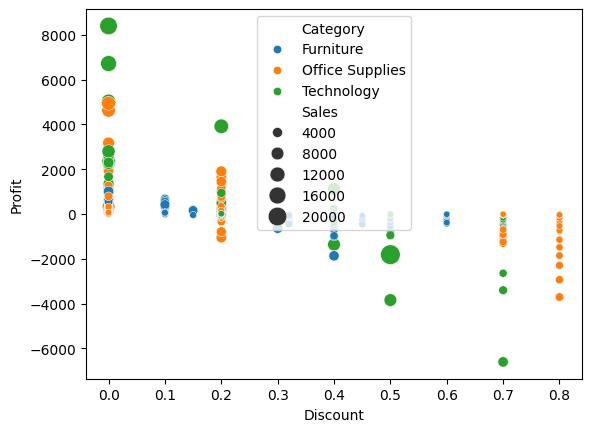

In [ ]:
# task 3 


scatter_plot = sns.scatterplot(x='Discount', y='Profit', hue='Category', size='Sales', data=df, sizes=(20, 200))
#sales is visible only due to size we can see big circles meaning big sales 

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Profit Positive
Row ID,0.000000e+00,-0.001795,-0.000049,-0.001601,0.000826,0.023043,-7.632783e-17
Postal Code,-1.795308e-03,0.000000,-0.021795,-0.001192,0.005650,-0.024511,-2.249914e-02
Sales,-4.876013e-05,-0.021795,0.000000,-0.126631,0.028778,-0.039342,-1.844760e-03
Quantity,-1.600595e-03,-0.001192,-0.126631,0.000000,0.009501,-0.168238,6.999113e-03
Discount,8.255207e-04,0.005650,0.028778,0.009501,0.000000,0.323863,-9.979534e-02
Profit,2.304266e-02,-0.024511,-0.039342,-0.168238,0.323863,0.000000,-4.558071e-01
Profit Positive,-7.632783e-17,-0.022499,-0.001845,0.006999,-0.099795,-0.455807,0.000000e+00


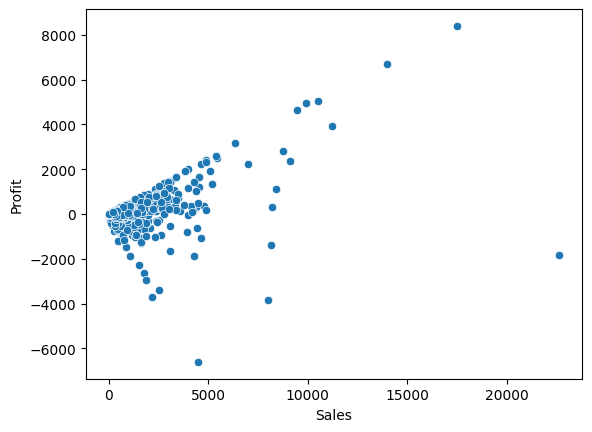

In [18]:
# task 4


pearson_corr = df.corr(method='pearson',numeric_only=True)
spearman_corr = df.corr(method='spearman',numeric_only=True)
correlation_disagreement = pearson_corr - spearman_corr
scatter_plot_disagreement = sns.scatterplot(x='Sales', y='Profit', data=df)

#Just because two things change together does not mean one caused the other.
correlation_disagreement

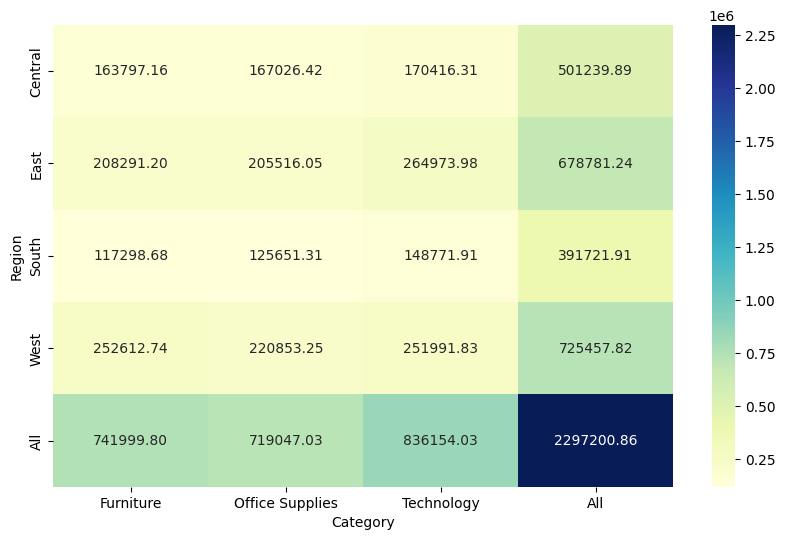

In [ ]:
# task 5

table = pd.pivot_table(df, values='Sales', index='Region', columns='Category', aggfunc='sum', margins=True)
plt.figure(figsize=(10, 6))
heatmap = sns.heatmap(table, annot=True, fmt=".2f", cmap="YlGnBu")
# technology category has highest revenue for us as we can observe from the heatmap.


<AxesSubplot: xlabel='Order Date'>

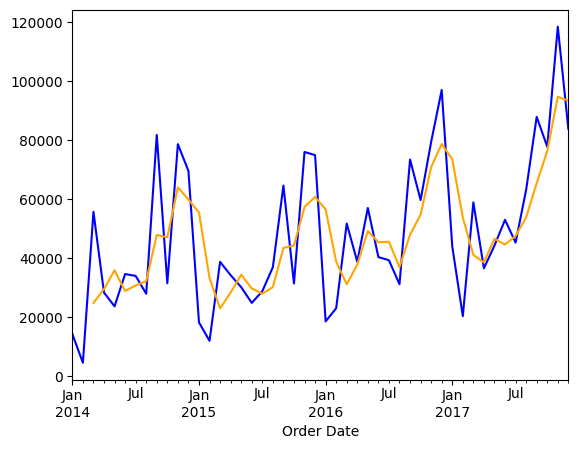

In [ ]:
# task 6
df['Order Date'] = pd.to_datetime(df['Order Date'])
trend = df.resample('M', on='Order Date')['Sales'].sum()
noise = df.resample('M', on='Order Date')['Sales'].sum().diff()
rolling_avg = trend.rolling(window=3).mean()
plot=trend.plot(label='Monthly Sales', color='blue')
rolling_avg.plot(label='3-Month Rolling Average', color='orange')
# rolling average smooths out the noise in data and it helps us to identify the trends more carefully.

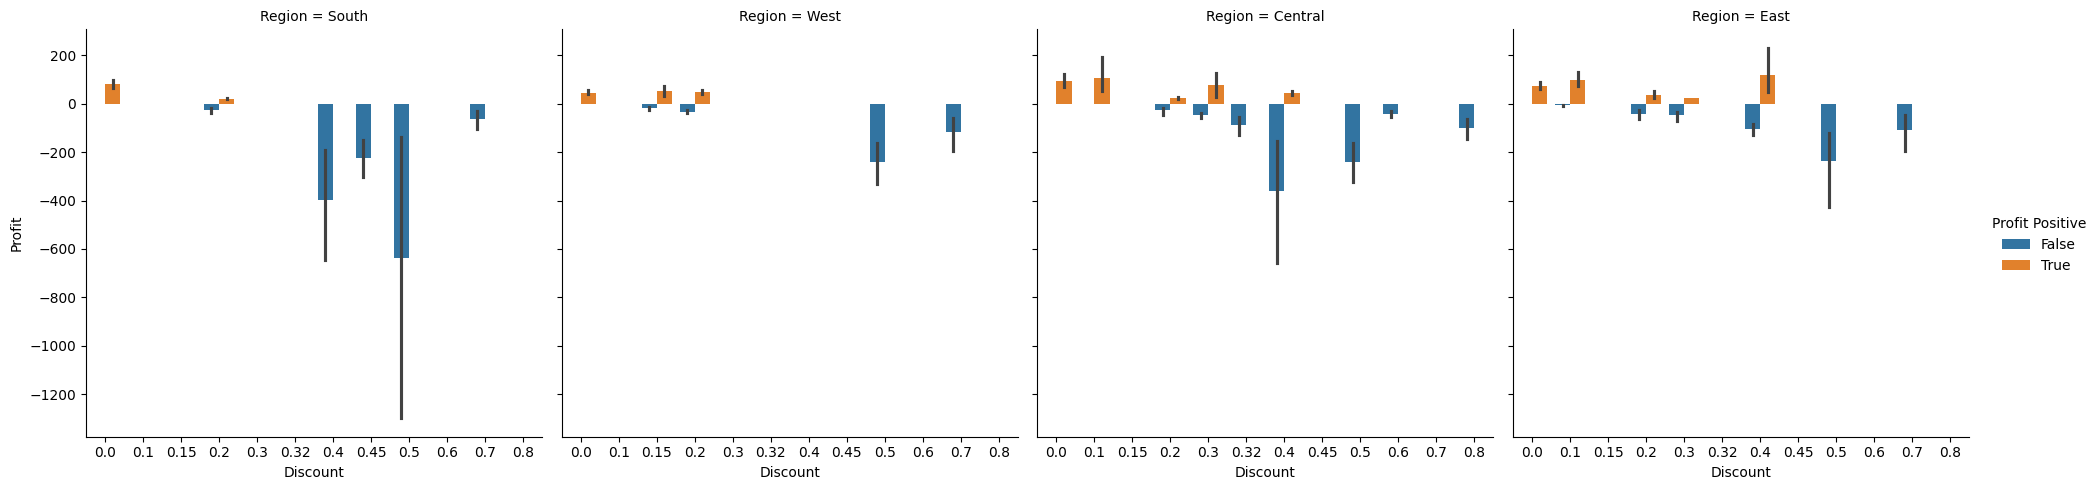

In [ ]:
# task 7
df['Profit Positive'] = df['Profit'] > 0
facet = sns.catplot(x='Discount', y='Profit', hue='Profit Positive', col='Region', data=df, kind='bar')


# in south region using catplot with bar graph we can see a visuall difference between positive and negative profit with respect to discount.

Text(10, 10, 'Most Profitable Order\nProfit: 8399.976')

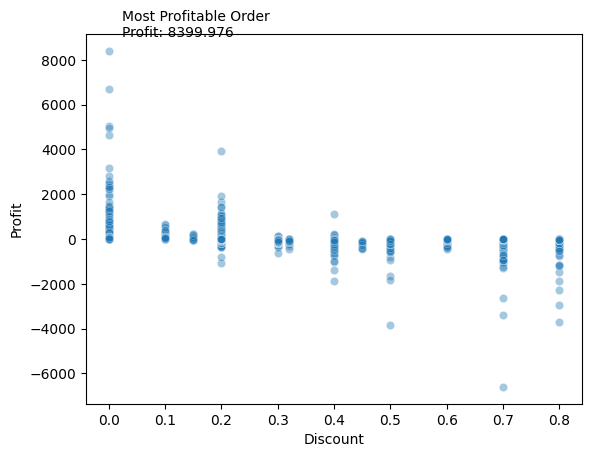

In [20]:
# task 8


scatter_plot_overplotting = sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.4)
# I used alpha to fix overplotting because it allows us to see the density of points
annotate = df.loc[df['Profit'].idxmax()]
plt.annotate(f'Most Profitable Order\nProfit: {annotate["Profit"]}', xy=(annotate['Discount'], annotate['Profit']), xytext=(10, 10), textcoords='offset points')